## ECMWF

In [40]:
#請確保已安裝Herbie(pip install Herbie-data)
from herbie import Herbie
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

from herbie import paint
from herbie.toolbox import EasyMap, pc
from scipy.interpolate import griddata
import scipy.ndimage
from PIL import Image

import metpy.calc as mpcalc

In [9]:
H = Herbie("2026-3-16-00", model="ifs", product="oper", fxx=120)

H.grib, H.idx

✅ Found ┊ model=ifs ┊ product=oper ┊ 2026-Mar-16 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws


('https://ecmwf-forecasts.s3.eu-central-1.amazonaws.com/20260316/00z/ifs/0p25/oper/20260316000000-120h-oper-fc.grib2',
 'https://ecmwf-forecasts.s3.eu-central-1.amazonaws.com/20260316/00z/ifs/0p25/oper/20260316000000-120h-oper-fc.index')

In [10]:
ds_2=H.xarray("100u")
ds_2=ds_2.sel(latitude=slice(25, 21,4), longitude=slice(112, 116,4))
ds_3=H.xarray("100v")
ds_3=ds_3.sel(latitude=slice(25, 21,4), longitude=slice(112, 116,4))
ds_4=H.xarray("100[u|v]").herbie.with_wind()
ds_4=ds_4.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_6=H.xarray(":msl:")
ds_6=ds_6.sel(latitude=slice(25, 21), longitude=slice(112, 116))

/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_var

/opt/anaconda3/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(1.0, 1.0, 'MSLP and 100 m wind(smoothed)')

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs

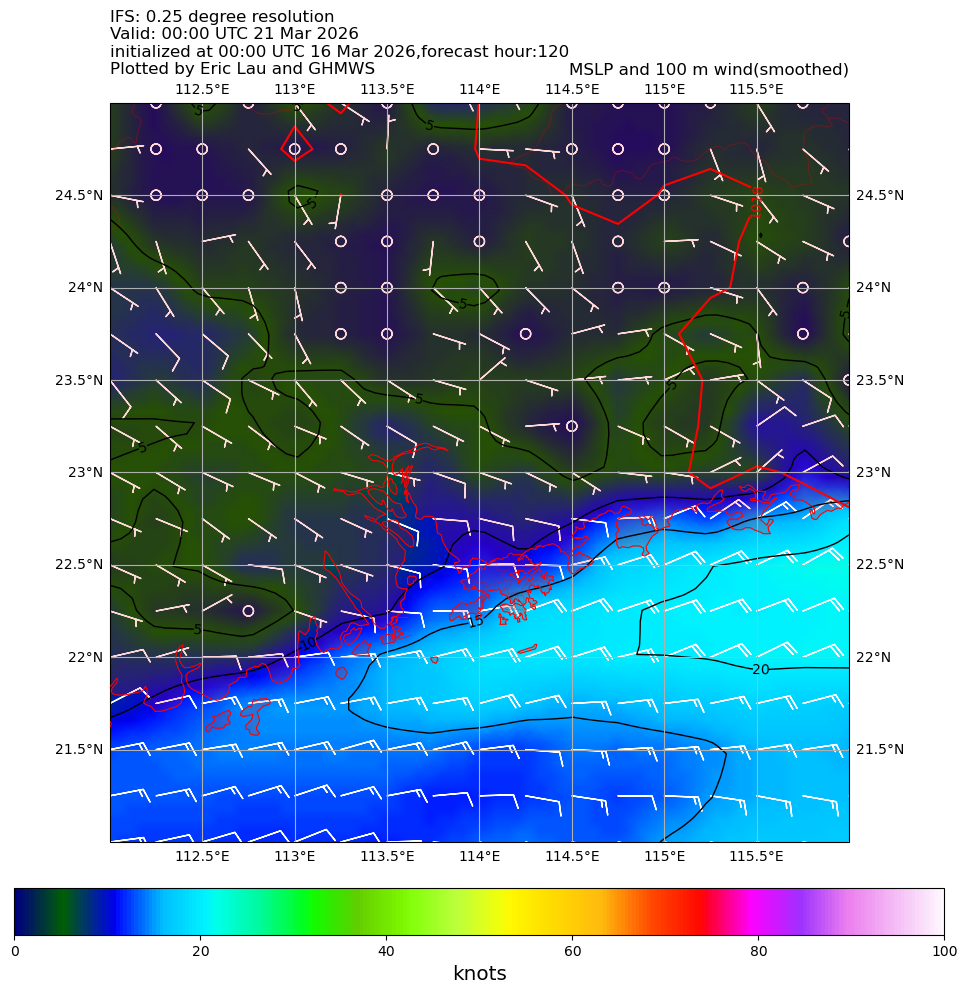

In [11]:
ax = EasyMap("10m", crs=ds_2.herbie.crs, figsize=[12, 12],color='red').STATES().BORDERS().ax
ds_5=scipy.ndimage.zoom(ds_4.si100,4,order=1)
longitude=scipy.ndimage.zoom(ds_4.longitude,4,order=1)
latitude=scipy.ndimage.zoom(ds_4.latitude,4,order=1)
p = ax.pcolormesh(
    longitude,
    latitude,
    ds_5*3.6/1.852,
    transform=pc,
    cmap="gist_ncar",
    vmin=0,
    vmax=100,
    shading='gouraud'
#    **paint.NWSTemperature.kwargs2,
)
y=plt.colorbar(
     p, ax=ax, orientation="horizontal", pad=0.05,cmap='nipy_spectral')
#y=plt.colorbar(
#    p, ax=ax, orientation="horizontal", pad=0.05, cmap="gist_ncar")
y.set_label('knots',size='x-large')
ax.barbs(ds_2.longitude,ds_3.latitude,ds_2.u100*3.6/1.852,ds_3.v100*3.6/1.852,barbcolor='w')
#ds_5=scipy.ndimage.zoom(ds.si100*3.6/1.852,7,order=1)
#longitude=scipy.ndimage.zoom(ds.longitude,7,order=1)
#latitude=scipy.ndimage.zoom(ds.latitude,7,order=1)
x=plt.contour(longitude, latitude, ds_5*3.6/1.852,levels=np.arange(0,100,5),colors='k',linewidths=1, transform=pc)
plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
z=plt.contour(ds_6.longitude, ds_6.latitude, ds_6.msl/100,levels=np.arange(880,1060,2),colors='red',transform=pc)
plt.clabel(z, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
ax.set_title(
    f"{ds_4.model.upper()}: 0.25 degree resolution\nValid: {ds_4.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()}\ninitialized at {ds_4.time.dt.strftime('%H:%M UTC %d %b %Y').item()},forecast hour:{H.fxx}\nPlotted by Eric Lau and GHMWS",
    loc="left",color='k'
)
gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
#ax.set_extent([113,115,21.5,23.5])
ax.set_title(f"MSLP and 100 m wind(smoothed)", loc="right")

In [63]:
H = Herbie("2026-3-28-18", model="ifs",product='scda',fxx=84)
G = Herbie("2026-3-28-18", model="ifs",product='scda',fxx=60)

✅ Found ┊ model=ifs ┊ product=scda ┊ 2026-Mar-28 18:00 UTC F84 ┊ GRIB2 @ google ┊ IDX @ local
✅ Found ┊ model=ifs ┊ product=scda ┊ 2026-Mar-28 18:00 UTC F60 ┊ GRIB2 @ google ┊ IDX @ local


In [64]:
ds=H.xarray(":tp:")
ds_2=G.xarray(":tp:")
ds=ds.sel(latitude=slice(30, 15), longitude=slice(105, 125))
ds_2=ds_2.sel(latitude=slice(30, 15), longitude=slice(105, 125))

/opt/anaconda3/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(1.0, 1.0, 'past 24 hours precipitation')

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


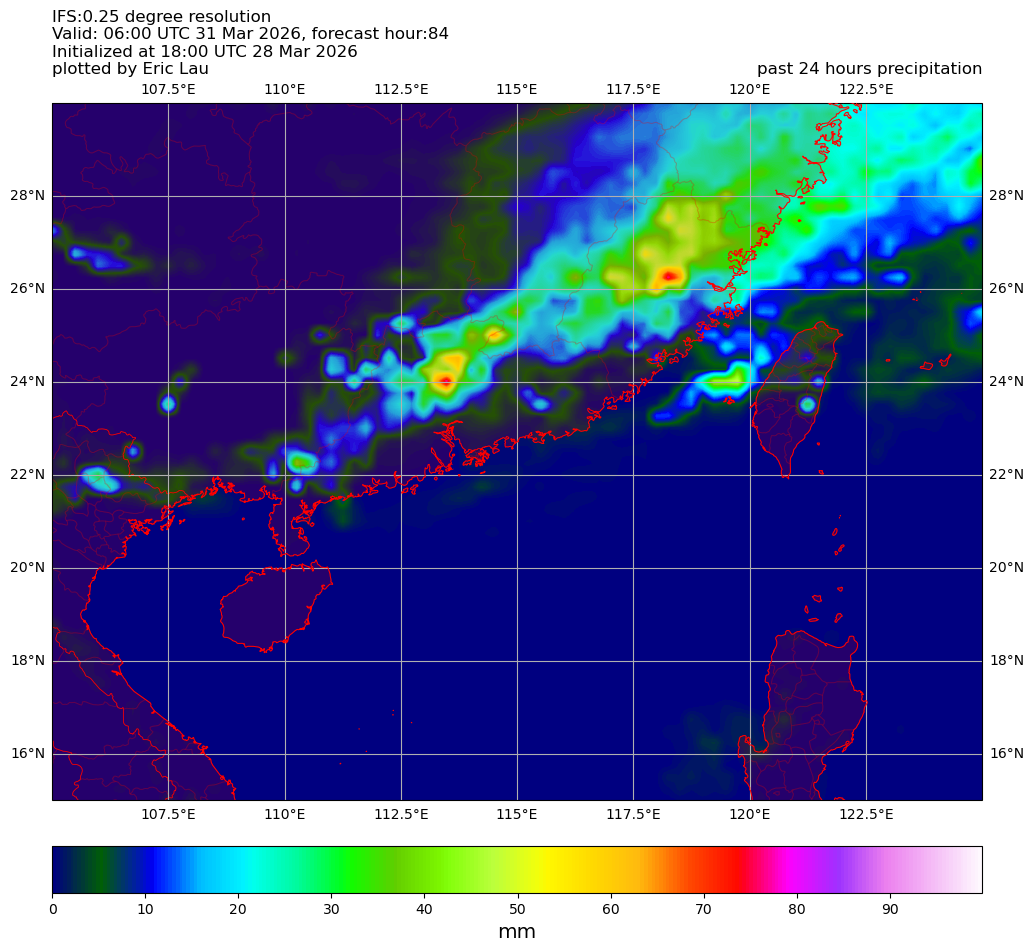

In [ ]:
ax = EasyMap("10m", crs=ds_2.herbie.crs, figsize=[12, 12],color='red').STATES().BORDERS().ax
ds_3=scipy.ndimage.zoom(ds.tp*1000-ds_2.tp*1000,4,order=1)
longitude=scipy.ndimage.zoom(ds.longitude,4,order=1)
latitude=scipy.ndimage.zoom(ds.latitude,4,order=1)
p = ax.contourf(
    longitude,
    latitude,
    ds_3,
    transform=pc,
    cmap='gist_ncar',
#    levels=np.arange(0,100)
    levels=np.arange(0,100,0.1)
#    **paint.NWSTemperature.kwargs2,
)
z=plt.colorbar(
    p, ax=ax, orientation="horizontal", pad=0.05
)
z.set_label('mm',size='x-large',color='k')
#plt.clabel(p, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#ax.text(longitude[74],latitude[118],f'{q}\nL',color='red',ha='center',size=16,fontweight='bold')
ax.set_title(
    f"{ds_2.model.upper()}:0.25 degree resolution\nValid: {ds.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()}, forecast hour:{H.fxx}\nInitialized at {ds_2.time.dt.strftime('%H:%M UTC %d %b %Y').item()}\nplotted by Eric Lau",
    loc="left",
color='black')
gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
#ax.set_extent([110,120,18,26])
ax.set_title("past 24 hours precipitation", loc="right",color='black')

## GFS

In [5]:
H = Herbie("2026-3-16-00", model="gfs",product='pgrb2.0p25',fxx=120)

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-Mar-16 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws


In [6]:
ds_4 = H.xarray(":UGRD:10 m above ground:")
ds_5 = H.xarray(":VGRD:10 m above ground:")
ds_6 = H.xarray(":UGRD:10 m above ground|VGRD:10 m above ground:").herbie.with_wind()
ds_2=H.xarray(":PRMSL:")
ds_2=ds_2.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_4=ds_4.sel(latitude=slice(25,21), longitude=slice(112, 116))
ds_5=ds_5.sel(latitude=slice(25,21), longitude=slice(112, 116))
ds_6=ds_6.sel(latitude=slice(25,21), longitude=slice(112, 116))

👨🏻‍🏭 Created directory: [/Users/eknlau/data/gfs/20260316]


/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_var

/opt/anaconda3/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(1.0, 1.0, 'MSLP and 10m wind(smoothed)')

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs

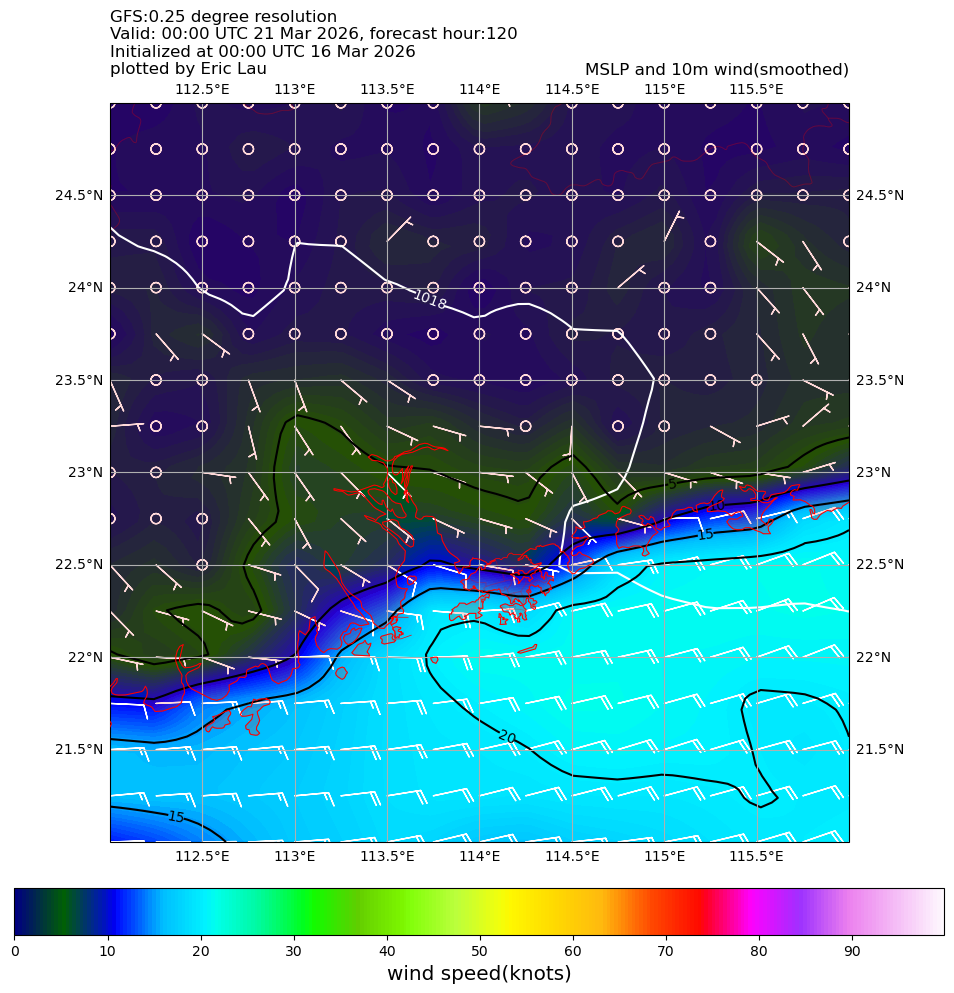

In [8]:
ax = EasyMap("10m", crs=ds_2.herbie.crs, figsize=[12, 12],color='red').STATES().BORDERS().ax
ds_3=scipy.ndimage.zoom(ds_6.si10,4,order=1)
ds_8=scipy.ndimage.zoom(ds_2.prmsl,4,order=1)
longitude=scipy.ndimage.zoom(ds_6.longitude,4,order=1)
latitude=scipy.ndimage.zoom(ds_6.latitude,4,order=1)
p = ax.contourf(
    longitude,
    latitude,
    ds_3*3.6/1.852,
    transform=pc,
    cmap='gist_ncar',
#    levels=np.arange(0,100)
    levels=np.arange(0,100,0.1)
#    **paint.NWSTemperature.kwargs2,
)
z=plt.colorbar(
    p, ax=ax, orientation="horizontal", pad=0.05
)
z.set_label('wind speed(knots)',size='x-large',color='k')
y=plt.contour(longitude,latitude,ds_8/100,levels=np.arange(880,1060,2),colors='white',transform=pc)
ax.barbs(ds_4.longitude,ds_5.latitude,ds_4.u10*3.6/1.852,ds_5.v10*3.6/1.852,barbcolor='w',rounding=True)
x=plt.contour(longitude,latitude,ds_3*3.6/1.852,levels=np.arange(0,100,5),colors='k',transform=pc)
plt.clabel(y, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#ax.text(longitude[74],latitude[118],f'{q}\nL',color='red',ha='center',size=16,fontweight='bold')
ax.set_title(
    f"{ds_2.model.upper()}:0.25 degree resolution\nValid: {ds_2.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()}, forecast hour:{H.fxx}\nInitialized at {ds_2.time.dt.strftime('%H:%M UTC %d %b %Y').item()}\nplotted by Eric Lau",
    loc="left",
color='black')
gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
#ax.set_extent([110,120,18,26])
ax.set_title("MSLP and 10m wind(smoothed)", loc="right",color='black')

## AIFS

In [12]:
H = Herbie("2026-3-16-00", model="aifs", product="oper", fxx=120)

H.grib, H.idx

✅ Found ┊ model=aifs ┊ product=oper ┊ 2026-Mar-16 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws


('https://ecmwf-forecasts.s3.eu-central-1.amazonaws.com/20260316/00z/aifs-single/0p25/oper/20260316000000-120h-oper-fc.grib2',
 'https://ecmwf-forecasts.s3.eu-central-1.amazonaws.com/20260316/00z/aifs-single/0p25/oper/20260316000000-120h-oper-fc.index')

In [13]:
ds_2=H.xarray("100u")
ds_2=ds_2.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_3=H.xarray("100v")
ds_3=ds_3.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_4=H.xarray("100[u|v]").herbie.with_wind()
ds_4=ds_4.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_6=H.xarray(":msl:")
ds_6=ds_6.sel(latitude=slice(25, 21), longitude=slice(112, 116))

👨🏻‍🏭 Created directory: [/Users/eknlau/data/aifs/20260316]


/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_var

/opt/anaconda3/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(1.0, 1.0, 'MSLP and 100 m wind(smoothed)')

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs

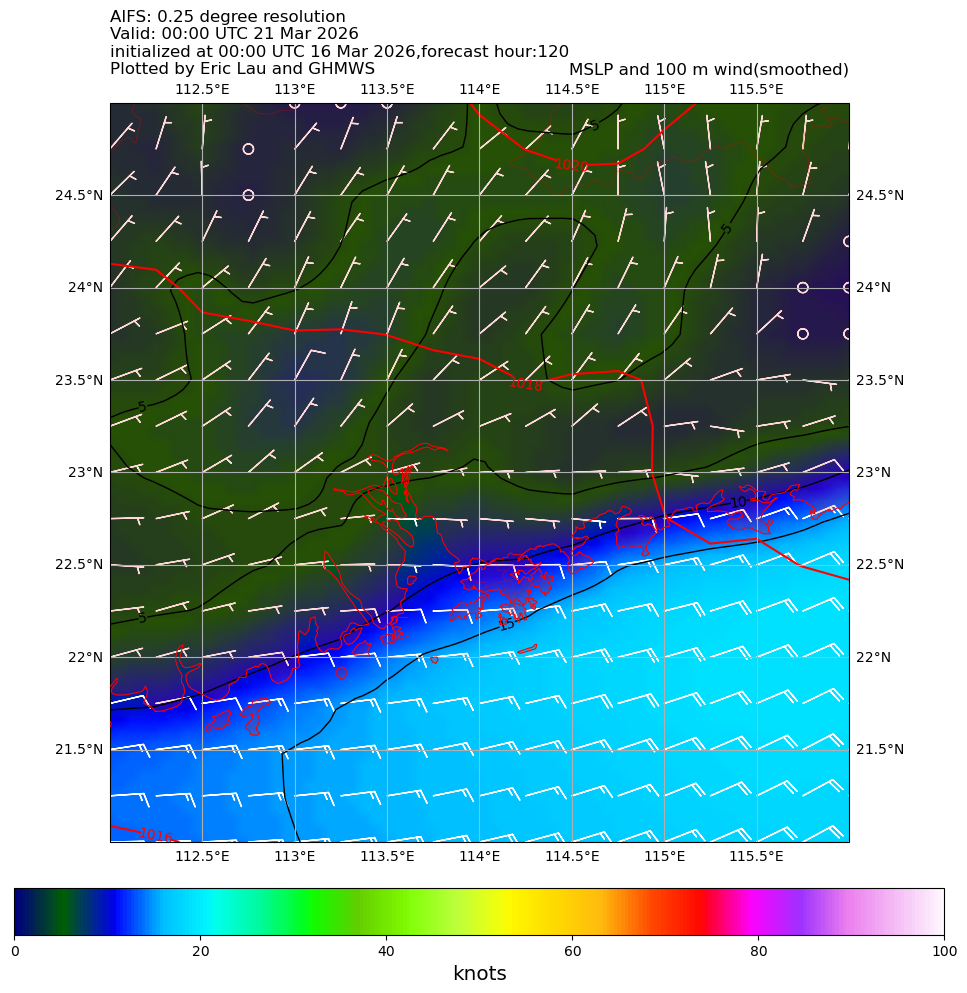

In [14]:
ax = EasyMap("10m", crs=ds_2.herbie.crs, figsize=[12, 12],color='red').STATES().BORDERS().ax
ds_5=scipy.ndimage.zoom(ds_4.si100,4,order=1)
longitude=scipy.ndimage.zoom(ds_4.longitude,4,order=1)
latitude=scipy.ndimage.zoom(ds_4.latitude,4,order=1)
p = ax.pcolormesh(
    longitude,
    latitude,
    ds_5*3.6/1.852,
    transform=pc,
    cmap="gist_ncar",
    vmin=0,
    vmax=100,
    shading='gouraud'
#    **paint.NWSTemperature.kwargs2,
)
y=plt.colorbar(
     p, ax=ax, orientation="horizontal", pad=0.05,cmap='nipy_spectral')
#y=plt.colorbar(
#    p, ax=ax, orientation="horizontal", pad=0.05, cmap="gist_ncar")
y.set_label('knots',size='x-large')
ax.barbs(ds_2.longitude,ds_3.latitude,ds_2.u100*3.6/1.852,ds_3.v100*3.6/1.852,barbcolor='w')
#ds_5=scipy.ndimage.zoom(ds.si100*3.6/1.852,7,order=1)
#longitude=scipy.ndimage.zoom(ds.longitude,7,order=1)
#latitude=scipy.ndimage.zoom(ds.latitude,7,order=1)
x=plt.contour(longitude, latitude, ds_5*3.6/1.852,levels=np.arange(0,100,5),colors='k',linewidths=1, transform=pc)
plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
z=plt.contour(ds_6.longitude, ds_6.latitude, ds_6.msl/100,levels=np.arange(880,1060,2),colors='red',transform=pc)
plt.clabel(z, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
ax.set_title(
    f"{ds_4.model.upper()}: 0.25 degree resolution\nValid: {ds_4.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()}\ninitialized at {ds_4.time.dt.strftime('%H:%M UTC %d %b %Y').item()},forecast hour:{H.fxx}\nPlotted by Eric Lau and GHMWS",
    loc="left",color='k'
)
gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
#ax.set_extent([113,115,21.5,23.5])
ax.set_title(f"MSLP and 100 m wind(smoothed)", loc="right")

In [45]:
H = Herbie("2026-3-28-18", model="ifs", product="scda",fxx=12)

✅ Found ┊ model=ifs ┊ product=scda ┊ 2026-Mar-28 18:00 UTC F12 ┊ GRIB2 @ google ┊ IDX @ google


In [46]:
ds=H.xarray(":10u:")
ds_1=H.xarray(":10v:")
ds_w=H.xarray(":10[u|v]:").herbie.with_wind()
ds_2=H.xarray(":u:850")
ds_3=H.xarray(":v:850")
ds_4=mpcalc.wind_speed(ds_2.u,ds_3.v)
ds_5=H.xarray(":r:850")
ds_6=H.xarray(":u:700")
ds_7=H.xarray(":v:700")
ds_8=mpcalc.wind_speed(ds_6.u,ds_7.v)
ds_9=H.xarray(":r:")
ds_10=H.xarray(":2t:")
ds_11=H.xarray("msl")
ds_12=H.xarray("gh:850")
#ds_10=H.xarray(":u:500")
#ds_11=H.xarray(":v:500")
#ds_12=H.xarray(":[500u|500v]:").herbie.with_wind()

In [47]:
ds=ds.sel(latitude=slice(30, 15,4), longitude=slice(105, 125,4))
ds_1=ds_1.sel(latitude=slice(30, 15,4), longitude=slice(105, 125,4))
ds_w=ds_w.sel(latitude=slice(30, 15), longitude=slice(105, 125))
ds_2=ds_2.sel(latitude=slice(30, 15,4), longitude=slice(105, 125,4))
ds_3=ds_3.sel(latitude=slice(30, 15,4), longitude=slice(105, 125,4))
ds_4=ds_4.sel(latitude=slice(30, 15), longitude=slice(105, 125))
ds_5=ds_5.sel(latitude=slice(30, 15), longitude=slice(105, 125))
ds_6=ds_6.sel(latitude=slice(30, 15,4), longitude=slice(105, 125,4))
ds_7=ds_7.sel(latitude=slice(30, 15,4), longitude=slice(105, 125,4))
ds_8=ds_8.sel(latitude=slice(30, 15), longitude=slice(105, 125))
ds_9=ds_9.sel(latitude=slice(30, 15), longitude=slice(105, 125))
ds_10=ds_10.sel(latitude=slice(30, 15), longitude=slice(105, 125))
ds_11=ds_11.sel(latitude=slice(30, 15), longitude=slice(105, 125))
ds_12=ds_12.sel(latitude=slice(30, 15), longitude=slice(105, 125))

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs

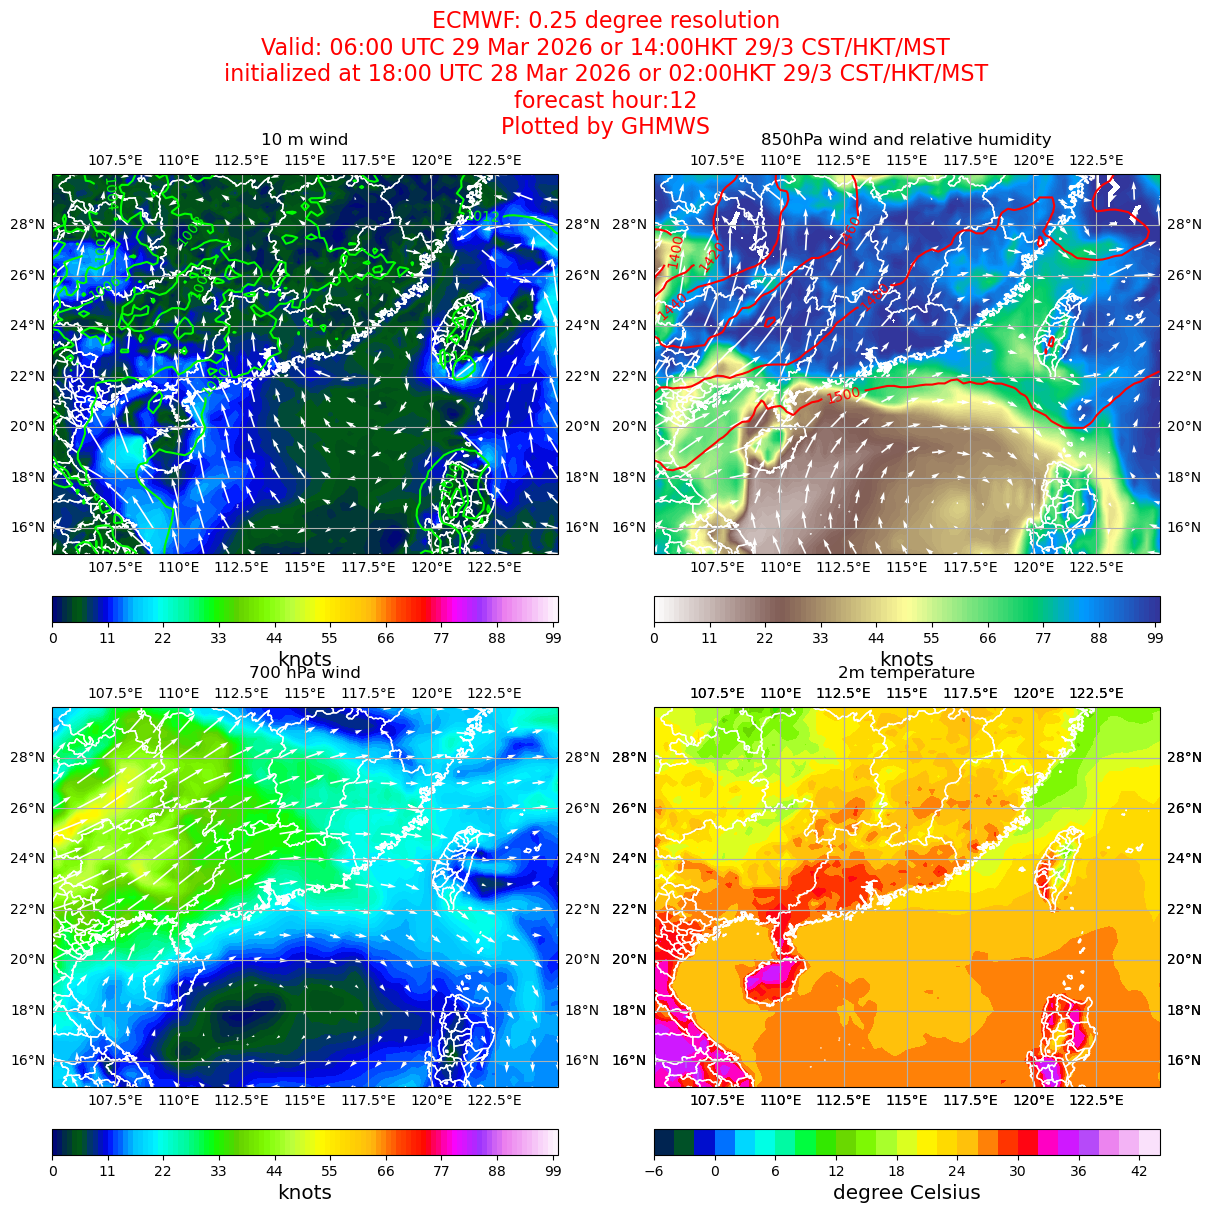

In [55]:
#ax = EasyMap("10m", crs=ds.herbie.crs, figsize=[12, 12]).STATES().BORDERS().ax
def plot_background(ax):
    ax.set_extent([105,125,15,30])
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1,edgecolor='w')
    ax.add_feature(cfeature.STATES, linewidth=1,edgecolor='w')
    ax.add_feature(cfeature.BORDERS, linewidth=1,edgecolor='w')
    #ax.tissot(rad_km=(800), lons=[114.174], lats=[22.302], alpha=0.3,color=None,linewidth=3,edgecolor='black')
    #ax.tissot(rad_km=(400), lons=[114.174], lats=[22.302], alpha=0.3,color=None,linewidth=3,edgecolor='yellow')
    #ax.tissot(rad_km=(200), lons=[114.174], lats=[22.302], alpha=0.3,color=None,linewidth=3,edgecolor='orange')
    #ax.tissot(rad_km=(100), lons=[114.174], lats=[22.302], alpha=0.3,color=None,linewidth=3,edgecolor='red')
    gl=ax.gridlines(draw_labels=True)
    gl.xlabels_top = False
    gl.ylabels_left = False
    return ax
fig, axarr=plt.subplots(nrows=2, ncols=2, figsize=(12, 12), constrained_layout=True,
                          subplot_kw={'projection': ccrs.PlateCarree()})
#add_metpy_logo(fig, 140, 120, size='small')
axlist = axarr.flatten()
for ax in axlist:
    plot_background(ax)
#ds_9=scipy.ndimage.zoom(ds.mucape,2,order=1)
#longitude=scipy.ndimage.zoom(ds.longitude,2,order=1)
#latitude=scipy.ndimage.zoom(ds.latitude,2,order=1)
p = axlist[0].contourf(
    ds_w.longitude,
    ds_w.latitude,
    ds_w.si10*3.6/1.852,
    transform=pc,
    cmap="gist_ncar",
    levels=np.arange(0,101,1),
#    **paint.NWSTemperature.kwargs2,
)
axlist[0].quiver(ds.longitude,ds.latitude,ds.u10*3.6/1.852,ds_1.v10*3.6/1.852,transform=pc,color='w')
axlist[0].set_title(f'10 m wind')
cb1 = fig.colorbar(p, ax=axlist[0], orientation='horizontal')
cb1.set_label(f'knots', size='x-large')
x=axlist[0].contour(ds_11.longitude,ds_11.latitude,ds_11.msl/100,levels=np.arange(960,1050,2),colors='lime',transform=pc)
#z=plt.contour(ds_2.longitude, ds_2.latitude, ds_2.msl/100,levels=np.arange(990,1040,2),cmap='gist_ncar',transform=pc)
#plt.clabel(z, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#z=axlist[0].contour(ds.longitude,ds.latitude, ds.d2m-273.15,levels=np.arange(-10,40,0.1),colors='w', transform=pc)
#z1=plt.contour(ds_1.longitude, ds_1.latitude,ds_1.t2m-273.15,levels=np.arange(7,8,1),cmap='Reds',transform=pc)
#plt.clabel(z, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)

q=axlist[1].contourf(
    ds_4.longitude,
    ds_4.latitude,
    ds_5.r,
    transform=pc,
    cmap="terrain_r",
    levels=np.arange(0,101,1)
#    **paint.NWSTemperature.kwargs2,
)
t=axlist[1].contour(ds_12.longitude,ds_12.latitude,ds_12.gh,levels=np.arange(1300,2900,20),colors='red',transform=pc)
plt.clabel(t, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
axlist[1].set_title(f'850hPa wind and relative humidity')
axlist[1].quiver(ds_2.longitude,ds_2.latitude,ds_2.u*3.6/1.852,ds_3.v*3.6/1.852,color='w',transform=pc)
g=plt.colorbar(
     q,ax=axlist[1], orientation="horizontal", cmap='gist_ncar')
g.set_label('knots',size='x-large')

r=axlist[2].contourf(
    ds_5.longitude,
    ds_5.latitude,
    ds_8*3.6/1.852,
    transform=pc,
    cmap="gist_ncar",
    levels=np.arange(0,101,1),
#    **paint.NWSTemperature.kwargs2,
)
axlist[2].set_title(f'700 hPa wind')
axlist[2].quiver(ds_2.longitude,ds_2.latitude,ds_6.u*3.6/1.852,ds_7.v*3.6/1.852,color='w',transform=pc)
r=plt.colorbar(
     r,ax=axlist[2], orientation="horizontal", cmap='gist_ncar')
r.set_label('knots',size='x-large')

#x=axlist[3].contourf(
#    ds_8.longitude,
#    ds_8.latitude,
#    ds_8*3.6/1.852,
#    transform=pc,
#    cmap="gist_ncar",
#    levels=np.arange(0,101,1),
#    **paint.NWSTemperature.kwargs2,
#)
#axlist[3].set_title(f'700hPa wind')
#axlist[3].quiver(ds_6.longitude,ds_7.latitude,ds_6.u*3.6/1.852,ds_7.v*3.6/1.852,color='w',transform=pc)
#x=plt.colorbar(
#     x,ax=axlist[3], orientation="horizontal", cmap='gist_ncar')
#x.set_label('knots',size='x-large')

g=axlist[3].contourf(ds_10.longitude,ds_10.latitude,ds_10.t2m-273.15,levels=np.arange(-6,46,2),cmap='gist_ncar',transform=pc)
#h=axlist[3].contour(ds_9.longitude,ds_9.latitude,ds_9.r[0],levels=np.arange(0,101,10),colors='w',transform=pc)
i=plt.colorbar(
     g,ax=axlist[3], orientation="horizontal", cmap='gist_ncar')
i.set_label('degree Celsius',size='x-large')
axlist[3].set_title(f'2m temperature')
#plt.clabel(h, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)

#j=axlist[5].contourf(ds_3.longitude,ds_3.latitude,np.sqrt((ds.u10-ds_6.u)**2+(ds_1.v10-ds_7.v)**2)*3.6/1.852,levels=np.arange(0,100),cmap='gist_ncar',transform=pc)
#k=axlist[5].contour(ds_3.longitude,ds_3.latitude,np.sqrt((ds.u10-ds_6.u)**2+(ds_1.v10-ds_7.v)**2)*3.6/1.852,levels=np.arange(0,100,5),colors='w',transform=pc)
#l=plt.colorbar(
#     j,ax=axlist[5], orientation="horizontal", cmap='gist_ncar')
#l.set_label('knots',size='x-large')
#axlist[5].set_title(f'10m to 3000 m height wind shear')
#plt.clabel(k, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)

#j=axlist[5].contourf(ds_12.longitude,ds_12.latitude,ds_12.ws[5]*3.6/1.852,levels=np.arange(0,101,1),cmap='gist_ncar',transform=pc)
#k=axlist[5].quiver(ds_10.longitude,ds_11.latitude,ds_10.u*3.6/1.852,ds_11.v*3.6/1.852,color='w',transform=pc)
#l=plt.colorbar(
#     j,ax=axlist[5], orientation="horizontal", cmap='gist_ncar')
#l.set_label('knots',size='x-large')
#axlist[5].set_title(f'500hPa wind')
fig.suptitle(
    f"ECMWF: 0.25 degree resolution\nValid: {ds.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()} or 14:00HKT 29/3 CST/HKT/MST\ninitialized at {ds.time.dt.strftime('%H:%M UTC %d %b %Y').item()} or 02:00HKT 29/3 CST/HKT/MST\nforecast hour:{H.fxx}\nPlotted by GHMWS",
    color='red',fontsize=16
)

gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
#ax.set_extent([112,116,25,21])
#ax.set_title(ds.mucape.long_name, loc="right",color='red')
plt.show()

## GFS 6 hours precipitation

In [41]:
H=Herbie("2026-3-26-18", model="gfs", fxx=12)
#G=Herbie("2026-2-4-00", model="gfs", fxx=18)
#data=H.xarray(":SNOWD:surface")
#data_2=G.xarray(":WEASD:")
ds_1=H.xarray(":CSNOW:")
ds_2=H.xarray(":CFRZR:")
ds_3=H.xarray(":CICEP:")
ds_4=H.xarray(":CRAIN:")
ds_8=H.xarray(":APCP:surface:")
ds_5=H.xarray(":PRMSL:")
ds_6=H.xarray(":UGRD:100 m above ground")
ds_7=H.xarray(":VGRD:100 m above ground")
#data=data[1]
#ds_2=ds_2[1]
#ds_3=ds_3[1]
#ds_4=ds_4[1]
#data=data.sel(latitude=slice(36,7),longitude=slice(100,140))
#ds_2=ds_2.sel(latitude=slice(36,7),longitude=slice(100,140))
#ds_3=ds_3.sel(latitude=slice(36,7),longitude=slice(100,140))
#ds_4=ds_4.sel(latitude=slice(36,7),longitude=slice(100,140))
a=ds_1[1].csnow
b=ds_2[1].cfrzr
c=ds_3[1].cicep
d=ds_4[1].crain
e=ds_8.tp
#ds_8=ds_8.sel(lat=slice(50,30),lon=slice(120,145))
a=a.sel(latitude=slice(50,10),longitude=slice(100,145))
b=b.sel(latitude=slice(50,10),longitude=slice(100,145))
c=c.sel(latitude=slice(50,10),longitude=slice(100,145))
d=d.sel(latitude=slice(50,10),longitude=slice(100,145))
ds_5=ds_5.sel(latitude=slice(50,10),longitude=slice(100,145))
ds_6=ds_6.sel(latitude=slice(50,10,6),longitude=slice(100,145,6))
ds_7=ds_7.sel(latitude=slice(50,10,6),longitude=slice(100,145,6))

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-Mar-26 18:00 UTC F12 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.


Text(1.0, 1.0, 'mslp, wind,and 6 hours precipitation')

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


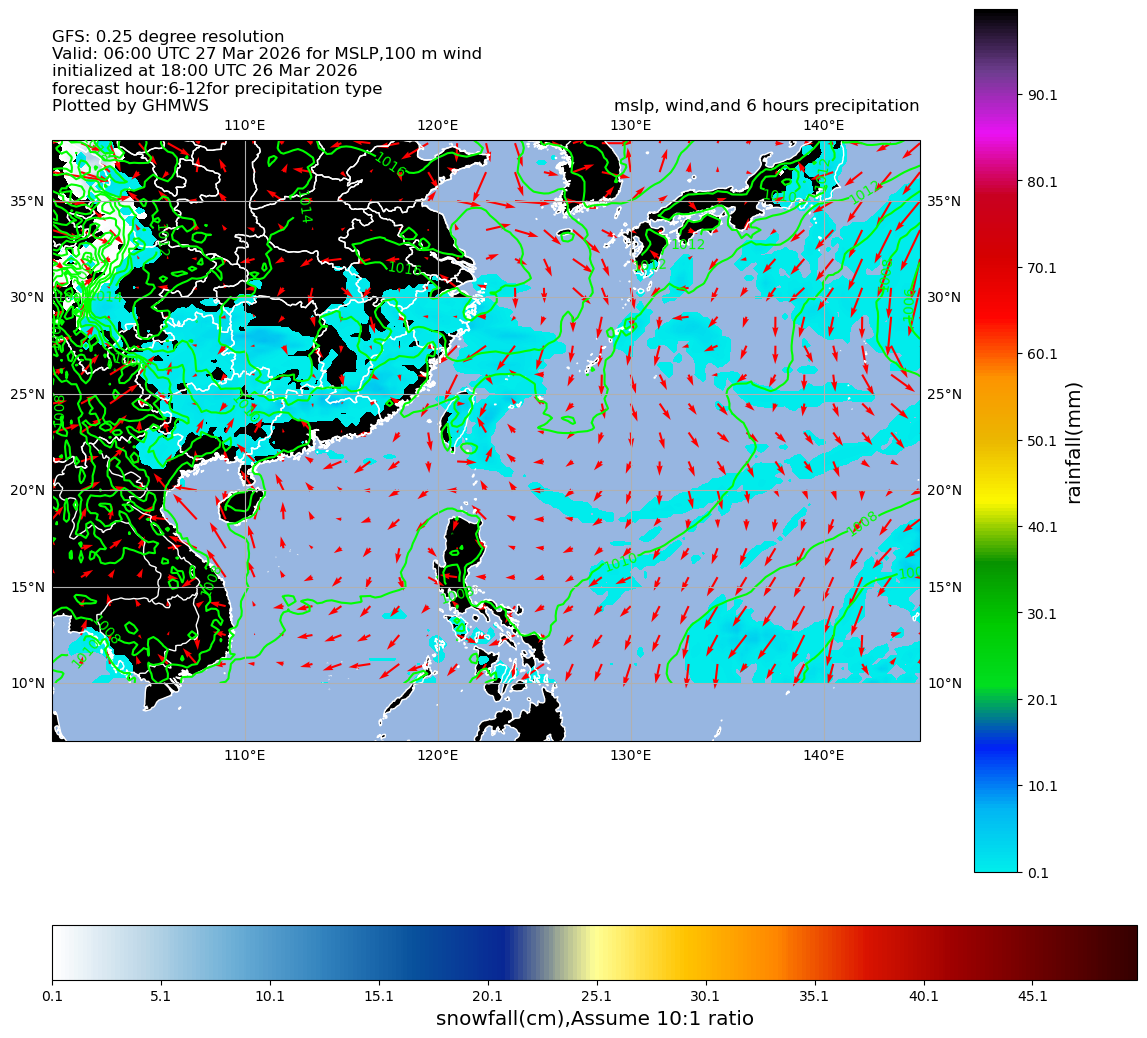

In [44]:
fig = plt.figure(figsize=(14,14))
crs = ccrs.PlateCarree()
ax = plt.axes(projection=crs)
lon_2d,lat_2d=np.meshgrid(a.longitude,a.latitude)
p = ax.contourf(
    lon_2d,
    lat_2d,
    a*e,
    cmap='nws.pcp_snow',
    #**paint.NWSPrecipitationSnow.kwargs2,
    levels=np.arange(0.1,50,0.1)
)

s=ax.contourf(
    d.longitude,
    d.latitude,
    d*e,
    cmap='radar.reflectivity',
#    **paint.NWSRef.kwargs2,
    levels=np.arange(0.1,100,0.1)
)
z=fig.colorbar(
    p, ax=ax, orientation="horizontal", pad=0.05
)
z.set_label('snowfall(cm),Assume 10:1 ratio',size='x-large',color='k')
g=fig.colorbar(
    s, ax=ax, orientation="vertical", pad=0.05
)
g.set_label('rainfall(mm)',size='x-large',color='k')
#z=ax.contour(ds_2.longitude,ds_2.latitude,ds_2.prmsl/100,colors='k',transform=pc)
#plt.clabel(z,fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
ax.set_extent([100,145,7,36])
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1,edgecolor='w')
ax.add_feature(cfeature.STATES, linewidth=1,edgecolor='w')
ax.add_feature(cfeature.BORDERS, linewidth=1,edgecolor='w')
ax.add_feature(cfeature.LAND, linewidth=1,facecolor='k')
ax.add_feature(cfeature.OCEAN)
#ax.tissot(rad_km=(800), lons=[114.175], lats=[22.3], alpha=0.3,color=None,linewidth=5,edgecolor='black')
#ax.tissot(rad_km=(400), lons=[114.175], lats=[22.3], alpha=0.3,color=None,linewidth=3,edgecolor='green')
#ax.tissot(rad_km=(200), lons=[114.175], lats=[22.3], alpha=0.3,color=None,linewidth=3,edgecolor='yellow')
#ax.tissot(rad_km=(100), lons=[114.175], lats=[22.3], alpha=0.3,color=None,linewidth=3,edgecolor='red')
#x=plt.contour(ds.longitude, ds.latitude, ds.si10*3.6/1.852,levels=np.arange(0,120,5), transform=pc)
ax.quiver(ds_6.longitude,ds_7.latitude,ds_6.u100*3.6/1.852,ds_7.v100*3.6/1.852,color='red',transform=pc)
z=plt.contour(ds_5.longitude, ds_5.latitude, ds_5.prmsl/100,levels=np.arange(960,1070,2),colors='lime', transform=pc)
plt.clabel(z, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
ax.set_title(
    f"GFS: 0.25 degree resolution\nValid: {b.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()} for MSLP,100 m wind\ninitialized at {b.time.dt.strftime('%H:%M UTC %d %b %Y').item()}\nforecast hour:{H.fxx-6}-{H.fxx}for precipitation type\nPlotted by GHMWS",
    loc="left",
)
#ax.set_title(f"violet:ice or sleet\nyellow:freezing rain",loc='center',color='red')
gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
ax.set_title("mslp, wind,and 6 hours precipitation", loc="right")

## CWA WRF 3km 雨量
1.請確保已經install cfgrib, 如未，在cmd 果度pip install cfgrib
2.請預留180MB儲存空間
3.Download data:TGFS係0-384小時每6小時，WRF係 0-84小時每6小時
TGFS(台灣全球模式）：https://cwaopendata.s3.ap-northeast-1.amazonaws.com/Model/M-A0060-000.grb2 
WRF(15km resolution): https://cwaopendata.s3.ap-northeast-1.amazonaws.com/Model/M-A0061-000.grb2
WRF(3km resolution): https://cwaopendata.s3.ap-northeast-1.amazonaws.com/Model/M-A0064-000.grb2
4.run 埋最頂果堆python library
5.以下是code

In [14]:
import cfgrib
data=cfgrib.open_dataset(f'/Users/eknlau/Downloads/M-A0064-012.grb2')
data
data.to_netcdf(f'/Users/eknlau/Downloads/wrf_2026032418.nc')
#check 邊個run

skipping variable: paramId==165 shortName='u10'
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/cfgrib/dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/opt/anaconda3/lib/python3.11/site-packages/cfgrib/dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='heightAboveGround' value=Variable(dimensions=(), data=2.0) new_value=Variable(dimensions=(), data=10.0)
skipping variable: paramId==166 shortName='v10'
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/cfgrib/dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/opt/anaconda3/lib/python3.11/site-packages/cfgrib/dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='heightAboveGround' value=V

In [ ]:
proj = ccrs.PlateCarree()
#Create an instance of figure and axes
fig = plt.figure(figsize=(12,12))
ax = plt.axes(projection=proj)

# Plot coastlines and political boundaries
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidths=0.5, linestyle='solid', edgecolor='k')
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidths=1.0, linestyle='solid', edgecolor='k')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidths=1.0, linestyle='solid', edgecolor='k')
ax.add_feature(cfeature.LAND.with_scale('10m'),facecolor='#EEEEEE')
p = ax.contourf(
    data[4].longitude,
    data[4].latitude,
    data[4].unknown,
    #np.sqrt(data[2].u[2]**2+data[2].v[2]**2)*3.6,
    transform=pc,
    cmap="radar.reflectivity",
    levels=np.arange(0.1,100,0.1)
)
#ax.tissot(rad_km=(800), lons=[114.175], lats=[22.3], alpha=0.15,color=None,linewidth=2,edgecolor='black')
#ax.tissot(rad_km=(400), lons=[114.175], lats=[22.3], alpha=0.15,color=None,linewidth=2,edgecolor='green')
#ax.tissot(rad_km=(200), lons=[114.175], lats=[22.3], alpha=0.15,color=None,linewidth=2,edgecolor='yellow')
#ax.tissot(rad_km=(100), lons=[114.175], lats=[22.3], alpha=0.15,color=None,linewidth=2,edgecolor='red')
#p = ax.pcolormesh(
#    ds.longitude, ds.latitude, ds.si10, transform=pc, cmap='gist_ncar')
#ds.longitude, ds.latitude, ds.si10*3.6/1.852, transform=pc, cmap='gist_ncar')
y=plt.colorbar(p, ax=ax, orientation="horizontal", pad=0.05)
y.set_label('mm',size='x-large')
gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
ax.set_title(
    f"CWA WRF:3km resolution\nValid:24/3 00Z\n23/3 00Z run,forecast hours:24\nPlotted by Eric Lau",
    loc="left",
)#改標題
ax.set_extent([105,120,21,30])#範圍
ax.set_title(f'accumulate precipitation', loc="right")

In [9]:
data[1]

<xarray.Dataset> Size: 25MB
Dimensions:            (y: 673, x: 1158)
Coordinates:
    time               datetime64[ns] 8B 2026-03-24T18:00:00
    step               timedelta64[ns] 8B 12:00:00
    heightAboveGround  float64 8B 2.0
    latitude           (y, x) float64 6MB 14.02 14.03 14.03 ... 32.12 32.12
    longitude          (y, x) float64 6MB 105.2 105.3 105.3 ... 140.9 140.9
    valid_time         datetime64[ns] 8B 2026-03-25T06:00:00
Dimensions without coordinates: y, x
Data variables:
    t2m                (y, x) float32 3MB ...
    d2m                (y, x) float32 3MB ...
    sh2                (y, x) float32 3MB ...
    r2                 (y, x) float32 3MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             138
    GRIB_centreDescription:  138
    GRIB_subCentre:          4
    Conventions:             CF-1.7
    institution:             138

## radar plot

In [ ]:
import requests
import pandas as pd 
import xarray as xr
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlopen
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from datetime import datetime, timezone

In [ ]:
x=pd.read_json("https://api.rainviewer.com/public/weather-maps.json")
y=x.radar.past[-1]['path']
y
print(x.radar.past[-1])
timestamp = x.radar.past[-1]['time']
dt_object_utc = datetime.fromtimestamp(timestamp, timezone.utc)
print(dt_object_utc)
url = f"https://tilecache.rainviewer.com{y}/1024/5/22.3/114.17/1/1_1.png"
url

In [ ]:
image=np.array(Image.open(urlopen(url)))
import matplotlib.font_manager
matplotlib.rcParams['font.family'] = ['PingFang HK']
fig = plt.figure(figsize=(10,10))
proj=ccrs.Mercator(min_latitude=20,max_latitude=28)
ax = plt.axes(projection=proj)
ax.set_extent([110,118,20,27])
ax.imshow(image,extent=[114.17-5.625,114.17+5.625,22.3-5.625,22.3+5.625],transform=ccrs.PlateCarree())
ax.tissot(rad_km=(200), lons=[114.1743], lats=[22.302], alpha=0.2,color=None,linewidth=1,edgecolor='k')
ax.tissot(rad_km=(100), lons=[114.1743], lats=[22.302], alpha=0.2,color=None,linewidth=1,edgecolor='k')
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidths=0.5, linestyle='solid', edgecolor='k')
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=1,edgecolor='red')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1,edgecolor='red')
ax.add_feature(cfeature.LAND.with_scale('10m'),facecolor='green',edgecolor='green')
ax.add_feature(cfeature.OCEAN.with_scale('10m'))
ax.set_title("雷達圖""\n""雷達時間：21:20HKT 30/3/2026, data from HKO, NMC and rainviewer,visualized by Eric Lau",size=14,color='k')
gl=ax.gridlines(draw_labels=True)
gl.xlabels_bottom = True
gl.ylabels_left = True
plt.show()